# 09. RLHF & Alignment

**Tier:** Training
**Estimated time:** 60 minutes
**Prerequisites:** 00–08
**Source material:** Stanford LLM curriculum, Lecture 5 (RLHF, PPO, DPO); @sairahul1

## What You'll Learn
- The three-stage alignment pipeline: **SFT → reward model → policy optimization (PPO)** — and the **DPO** shortcut that skips the reward model
- How a **reward model** learns human preferences from *pairwise comparisons* (the Bradley–Terry model), built from scratch
- Why a **KL penalty** to a reference model is essential, and how to implement **DPO** directly on preference pairs

## Why This Matters
Pretraining (07) gives knowledge; fine-tuning (08) gives a task. Neither teaches a model to be *helpful, honest, and harmless* — that's alignment. RLHF is why ChatGPT felt different from raw GPT-3. DPO is why modern open models can be aligned without the complexity of reinforcement learning. We'll implement the core of both on a transparent toy.

In [ ]:
import os

# Load .env if python-dotenv is installed; harmless if it isn't.
# Not required for this notebook (runs fully offline with NumPy).
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

## The three stages, in plain English

You can't write a loss function for "be helpful." So we learn it from human judgment:

1. **SFT (Supervised Fine-Tuning):** show the model good example responses and fine-tune (notebook 08). Now it follows instructions, but only imitates demonstrations.
2. **Reward model:** humans can't score responses on an absolute scale, but they *can* say "A is better than B." Collect many such comparisons and train a model to predict a scalar **reward** consistent with those preferences.
3. **Policy optimization (PPO):** use the reward model as an automatic judge and nudge the language model (the **policy**) to produce higher-reward responses — *while* a **KL penalty** keeps it close to the SFT model so it doesn't degenerate into gibberish that games the reward.

**DPO (Direct Preference Optimization)** later showed you can skip stage 2's separate reward model and the RL of stage 3 entirely: a clever loss optimizes the policy *directly* on the preference pairs. Same goal, far simpler.

We'll model a single prompt with a handful of candidate responses, each described by interpretable features.

In [1]:
import numpy as np
np.random.seed(0)

# Candidate responses to one prompt, each described by 3 features in [0,1]:
# [helpfulness, politeness, safety]. In a real system these come from the LLM's text.
responses = ["dump raw answer", "helpful + polite", "polite but useless",
             "helpful but rude", "unsafe shortcut"]
features = np.array([
    [0.7, 0.2, 0.9],   # dump raw answer
    [0.9, 0.9, 0.9],   # helpful + polite   <- what we hope alignment selects
    [0.2, 0.9, 0.9],   # polite but useless
    [0.9, 0.1, 0.9],   # helpful but rude
    [0.8, 0.5, 0.1],   # unsafe shortcut    <- must be suppressed
])

# The TRUE human preference (hidden from our models): values help & safety, mild politeness.
true_w = np.array([1.0, 0.5, 1.2])
true_reward = features @ true_w
for r, name in sorted(zip(true_reward, responses), reverse=True):
    print(f"  true reward {r:.2f}   {name}")

  true reward 2.43   helpful + polite
  true reward 2.03   helpful but rude
  true reward 1.88   dump raw answer
  true reward 1.73   polite but useless
  true reward 1.17   unsafe shortcut


## Stage 2: a reward model from pairwise preferences

Humans give us comparisons, not scores. The **Bradley–Terry** model says the probability a human prefers A over B is `sigmoid(r(A) − r(B))`. We generate noisy human comparisons from the hidden true reward, then fit a reward model `r(x) = w · features` by maximizing the likelihood of those preferences — i.e., minimizing `−log sigmoid(r(chosen) − r(rejected))`.

In [2]:
def sigmoid(z): return 1 / (1 + np.exp(-z))

# Generate a dataset of human preference pairs from the (hidden) true reward + noise.
def make_preferences(n=400):
    pairs = []
    for _ in range(n):
        i, j = np.random.choice(len(responses), 2, replace=False)
        # Noisy human: prefers the higher true reward, but not perfectly.
        p_i_wins = sigmoid(true_reward[i] - true_reward[j])
        if np.random.rand() < p_i_wins:
            pairs.append((i, j))     # (chosen, rejected)
        else:
            pairs.append((j, i))
    return pairs

prefs = make_preferences()
print("example preference pairs (chosen, rejected):", prefs[:5])

# Fit the reward model weights by gradient descent on the Bradley-Terry loss.
w = np.zeros(3)
lr = 0.1
for step in range(2000):
    grad = np.zeros(3)
    for c, r in prefs:
        diff = features[c] - features[r]
        # d/dw of -log sigmoid(w . diff) = -(1 - sigmoid(w.diff)) * diff
        grad += -(1 - sigmoid(w @ diff)) * diff
    w -= lr * grad / len(prefs)

print("\nlearned reward weights:", np.round(w, 2), " (true was", true_w, ")")
learned_reward = features @ w

example preference pairs (chosen, rejected): [(np.int64(0), np.int64(2)), (np.int64(2), np.int64(0)), (np.int64(0), np.int64(1)), (np.int64(3), np.int64(0)), (np.int64(4), np.int64(2))]



learned reward weights: [0.7  0.34 1.24]  (true was [1.  0.5 1.2] )


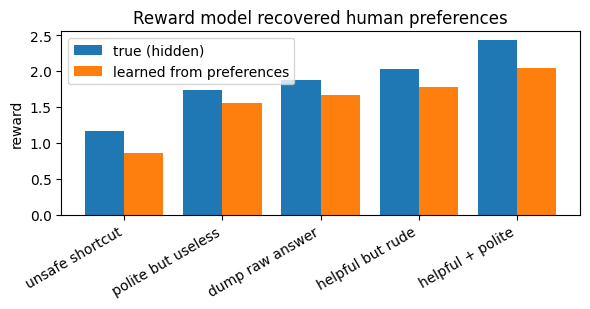

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
order = np.argsort(true_reward)
plt.figure(figsize=(6, 3.2))
x = np.arange(len(responses))
plt.bar(x - 0.2, true_reward[order], 0.4, label="true (hidden)")
plt.bar(x + 0.2, learned_reward[order], 0.4, label="learned from preferences")
plt.xticks(x, [responses[i] for i in order], rotation=30, ha="right")
plt.ylabel("reward"); plt.title("Reward model recovered human preferences"); plt.legend()
plt.tight_layout(); plt.show()

*The reward model never saw a single score — only 'A beats B' comparisons — yet it recovered the ranking, including that the unsafe shortcut is bad despite being helpful. That ranking is now an automatic judge.*

## Stage 3: optimize the policy (with a KL leash)

The **policy** is a distribution over responses, `π = softmax(θ)`. We want to maximize expected reward — but if we *only* maximize reward, the policy collapses onto whatever the (imperfect) reward model scores highest, exploiting its errors. So we subtract a **KL penalty** that keeps π near a reference policy `π_ref` (the SFT model). The objective:

```
maximize   E_π[reward]  −  β · KL(π ‖ π_ref)
```

In [4]:
def softmax(z):
    z = z - z.max(); e = np.exp(z); return e / e.sum()

ref = softmax(np.zeros(len(responses)))     # SFT reference = uniform here
theta = np.zeros(len(responses))            # policy logits, start = reference
beta = 0.5
history = []

for step in range(400):
    pi = softmax(theta)
    # Gradient of E_pi[R] - beta*KL(pi||ref) wrt logits theta (standard result):
    advantage = learned_reward - learned_reward @ pi          # center the reward
    kl_term = beta * (np.log(pi + 1e-9) - np.log(ref + 1e-9) + 1)
    grad = pi * (advantage - kl_term + (kl_term @ pi))
    theta += 0.5 * grad
    if step % 50 == 0:
        kl = float((pi * (np.log(pi + 1e-9) - np.log(ref + 1e-9))).sum())
        history.append((step, float(learned_reward @ pi), kl))

pi = softmax(theta)
print("Final policy (probability of choosing each response):")
for p, name in sorted(zip(pi, responses), reverse=True):
    print(f"  {p:.3f}  {name}")

Final policy (probability of choosing each response):
  0.397  helpful + polite
  0.231  helpful but rude
  0.187  dump raw answer
  0.148  polite but useless
  0.037  unsafe shortcut


*The policy shifts probability toward 'helpful + polite' (the reward-model favourite) without abandoning the reference entirely — the KL penalty is the leash that prevents reward hacking and keeps the model fluent.*

## DPO: skip the reward model

**Direct Preference Optimization** proves you don't need stages 2 and 3 separately. It optimizes the policy *straight* from the preference pairs with this loss:

```
L_DPO = −log sigmoid( β · [ (log π(y_w) − log π_ref(y_w)) − (log π(y_l) − log π_ref(y_l)) ] )
```

Intuitively: raise the policy's (reference-relative) log-prob of the **chosen** response and lower it for the **rejected** one. No reward model, no RL loop. Let's run it on the same preference data and confirm it lands in the same place.

In [5]:
theta_dpo = np.zeros(len(responses))
log_ref = np.log(ref + 1e-9)
beta = 0.5

for step in range(4000):
    pi = softmax(theta_dpo)
    log_pi = np.log(pi + 1e-9)
    grad = np.zeros(len(responses))
    for c, r in prefs:
        # reference-relative log-prob gap between chosen and rejected
        margin = beta * ((log_pi[c] - log_ref[c]) - (log_pi[r] - log_ref[r]))
        coef = beta * (1 - sigmoid(margin))         # weight from the DPO loss gradient
        # d(log pi[c])/dtheta = e_c - pi and d(log pi[r])/dtheta = e_r - pi; the -pi terms
        # cancel in (chosen - rejected), leaving a clean "push chosen up, rejected down".
        grad[c] += coef
        grad[r] -= coef
    theta_dpo += 0.1 * grad / len(prefs)

pi_dpo = softmax(theta_dpo)
print("DPO policy (no reward model, no RL):")
for p, name in sorted(zip(pi_dpo, responses), reverse=True):
    print(f"  {p:.3f}  {name}")

DPO policy (no reward model, no RL):
  0.413  helpful + polite
  0.281  dump raw answer
  0.148  helpful but rude
  0.124  polite but useless
  0.035  unsafe shortcut


*DPO reaches the same conclusion — concentrating on the helpful, polite, safe response — directly from preference pairs. This simplicity is why DPO and its variants dominate modern open-model alignment.*

## Exercises

In [6]:
# Exercise 1 (Warm-up): The KL coefficient beta
# Task: Re-run Stage 3 with beta = 0.05 and beta = 2.0. How does the final policy change?
# Hint: Small beta -> policy chases reward and collapses onto one response; large beta ->
#       policy barely moves from the uniform reference. This is the alignment tax tradeoff.

# YOUR CODE HERE

In [7]:
# Exercise 2 (Apply): Reward hacking
# Task: Corrupt the reward model so it OVER-rewards the 'unsafe shortcut' (e.g., set its
#       learned reward very high). Re-run Stage 3 with a tiny beta and watch the policy chase
#       the bad response. Then raise beta and show the KL leash mitigates it.
# Hint: This is a toy version of why the KL penalty (and good reward models) matter for safety.

# YOUR CODE HERE

In [8]:
# Exercise 3 (Extend): PPO vs DPO tradeoffs
# Task: In a comment, list two advantages of DPO over PPO-based RLHF and one situation where
#       you'd still want a separate reward model. Connect to evals (notebook 26, LLM-as-judge).
# Hint: Think about engineering complexity, stability, and reusability of a reward model.

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 3 (sample answer)
# DPO advantages: (1) no separate reward model to train/serve and no RL loop, so it's far
# simpler and more stable; (2) directly optimizes the preference objective, fewer moving
# parts to tune. You'd still want a standalone reward model when you need to SCORE arbitrary
# new outputs (e.g., best-of-n sampling, online RL, or as an automated judge in evals) —
# DPO bakes preferences into the policy but gives you no reusable scorer.
```
</details>

## Key Takeaways
- Alignment is a 3-stage pipeline: **SFT** (imitate good answers) → **reward model** (learn preferences from comparisons) → **PPO** (optimize the policy against that reward).
- A **reward model** is trained from *pairwise* human judgments via the Bradley–Terry loss — no absolute scores needed.
- The **KL penalty** to the SFT reference is the safety leash that prevents reward hacking and keeps outputs fluent.
- **DPO** collapses the reward model and RL into a single preference loss on the policy — simpler, stable, and now the default for open models.

## What's Next
Notebook **10 — Quantization**: now that the model is trained and aligned, how do we shrink it to run on cheaper hardware? We compress 32-bit weights down to 8 or 4 bits with minimal quality loss.